<a href="https://colab.research.google.com/github/Gayathridevi-gj/Online-Food-Delivery-Analysis-Data-Driven-Business-Insights/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

packages needed

In [1]:
import pandas as pd
import numpy as np
import datetime as dt

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

load data as df

In [4]:
df=pd.read_csv('/content/ONINE_FOOD_DELIVERY_ANALYSIS.csv')
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,NaN,NaN,Mumbai,NaN,RES295,Restaurant_500,Arabian,6/10/2024,...,132.0,Card,Delivered,NaN,DP835,2.0,4.0,Weekday,True,0.17
99996,ORD099997,CUST6158,NaN,Male,Mumbai,East,RES157,Restaurant_458,Arabian,4/22/2024,...,1078.0,NaN,Delivered,NaN,DP476,4.0,3.5,Weekday,False,-0.15
99997,ORD099998,CUST2155,NaN,NaN,Delhi,East,RES287,Restaurant_273,NaN,2/23/2024,...,NaN,COD,Cancelled,NaN,DP577,2.0,4.0,Weekday,True,0.47
99998,ORD099999,CUST3015,NaN,Female,Delhi,North,RES491,Restaurant_241,NaN,12/10/2024,...,NaN,NaN,Delivered,NaN,DP896,NaN,4.3,Weekday,NaN,0.44


data understanding

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df.head(10)

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,0:00,187.0,15.75,NaN,NaN,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,0:00,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,0:00,207.0,NaN,757.0,20.0,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,0:00,143.0,15.68,NaN,NaN,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,0:00,51.0,9.60,372.0,20.0,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12
5,ORD000006,CUST3161,37.0,Other,Chennai,East,RES810,Restaurant_153,Mexican,7/9/2024,0:00,56.0,4.00,NaN,300.0,NaN,Card,Delivered,NaN,DP119,3.0,4.6,Weekday,True,0.24
6,ORD000007,CUST2307,40.0,Other,Delhi,NaN,RES333,Restaurant_302,Chinese,2/14/2024,0:00,273.0,5.77,NaN,0.0,NaN,UPI,Delivered,NaN,DP624,2.0,4.5,Weekday,NaN,0.02
7,ORD000008,CUST5865,NaN,Male,NaN,North,RES696,Restaurant_41,Chinese,5/26/2024,0:00,NaN,21.69,3506.0,20.0,3486.0,UPI,Delivered,NaN,DP316,5.0,3.8,Weekend,NaN,0.18
8,ORD000009,CUST4356,NaN,Other,Delhi,Central,RES780,Restaurant_155,Italian,9/7/2024,0:00,NaN,8.55,525.0,100.0,425.0,NaN,Delivered,NaN,DP531,2.0,3.7,Weekend,True,0.08
9,ORD000010,CUST2404,NaN,Female,NaN,South,RES155,Restaurant_368,Chinese,1/22/2024,0:00,NaN,32.54,4691.0,50.0,4641.0,NaN,Delivered,NaN,DP338,4.0,4.5,Weekday,True,0.03


In [7]:
!pip install ydata_profiling
!pip install fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.5/400.5 kB 13.9 MB/s eta 0:00:00


In [8]:
import data_profiling
from data_profiling import ProfileReport

In [9]:
EDA = ProfileReport(df,title='EDA')
EDA

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 25/25 [00:13<00:00,  1.86it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,50093
Customer_Gender,24856
City,16726
Area,16685
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,16885
Order_Date,1014


Handling Missing Value

In [11]:
df['Customer_Age'].median()

39.0

In [12]:
age_median = df['Customer_Age'].median()
df['Customer_Age'] = df['Customer_Age'].fillna(age_median)

In [13]:
df['City']=df['City'].ffill()
df['Area']=df['Area'].ffill()
df['Cuisine_Type']=df['Cuisine_Type'].ffill()

In [14]:
df['Customer_Gender']=df['Customer_Gender'].ffill()

In [15]:
df['Order_Date']=df['Order_Date'].ffill()

In [16]:
ordertime_mode=df['Order_Time'].mode()


In [17]:
df['Order_Time'] = df['Order_Time'].ffill()

In [18]:
payment_mode=df['Payment_Mode'].mode()
df['Payment_Mode'] = df['Payment_Mode'].fillna(payment_mode)

checking outliers

In [19]:
df['Delivery_Rating'].unique()

array([ 5.,  4.,  2.,  3.,  1., nan])

In [20]:
drating_median=df['Delivery_Rating'].median()
df['Delivery_Rating'] = df['Delivery_Rating'].fillna(drating_median)

In [21]:
df['Peak_Hour'].unique()
df['Peak_Hour']=df['Peak_Hour'].ffill()

In [22]:
df['Cancellation_Reason'].unique()

array([nan, 'Late Delivery', 'Restaurant Issue', 'Customer Cancelled'],
      dtype=object)

In [23]:
df.loc[
    (df['Cancellation_Reason'].isnull()) & (df['Delivery_Time_Min'] >120.0 ) & (df['Order_Status']=='Cancelled'),
    'Cancellation_Reason',
] = 'Late Delivery'

In [24]:
((df['Order_Status']=='Cancelled')&(df['Cancellation_Reason'].isna())).sum()

np.int64(4054)

In [ ]:
df[(df['Order_Status'] == 'Cancelled') & (df['Cancellation_Reason'].isna())]

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
38,ORD000039,CUST9613,39.0,Other,Bangalore,East,RES110,Restaurant_500,Mexican,5/6/2024,0:00,31.0,30.53,672.0,50.0,622.0,COD,Cancelled,NaN,DP108,2.0,5.5,Weekday,False,0.38
94,ORD000095,CUST9324,39.0,Male,Hyderabad,South,RES508,Restaurant_85,Mexican,1/27/2024,0:00,NaN,NaN,NaN,NaN,NaN,Card,Cancelled,NaN,DP474,1.0,4.2,Weekend,True,0.07
134,ORD000135,CUST5179,39.0,Female,Delhi,South,RES373,Restaurant_172,Mexican,3/25/2024,0:00,65.0,NaN,636.0,50.0,586.0,Wallet,Cancelled,NaN,DP157,5.0,3.0,Weekday,False,0.10
156,ORD000157,CUST6249,18.0,Male,Chennai,North,RES625,Restaurant_96,Arabian,2/16/2024,0:00,NaN,2.09,287.0,100.0,187.0,UPI,Cancelled,NaN,DP206,3.0,3.2,Weekday,True,0.23
250,ORD000251,CUST5841,22.0,Male,Mumbai,West,RES667,Restaurant_360,Chinese,3/11/2024,0:00,NaN,1.12,NaN,50.0,NaN,Card,Cancelled,NaN,DP376,1.0,3.9,Weekday,False,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99839,ORD099840,CUST2210,39.0,Female,Chennai,West,RES113,Restaurant_109,Chinese,3/17/2024,0:00,NaN,NaN,NaN,100.0,NaN,Card,Cancelled,NaN,DP416,2.0,4.1,Weekend,True,0.50
99843,ORD099844,CUST5820,39.0,Female,Mumbai,West,RES438,Restaurant_32,Indian,5/26/2024,0:00,46.0,26.92,NaN,0.0,NaN,NaN,Cancelled,NaN,DP609,4.0,4.9,Weekend,False,0.28
99994,ORD099995,CUST9174,39.0,Female,Delhi,East,RES596,Restaurant_342,Italian,4/12/2024,0:00,NaN,NaN,3683.0,0.0,NaN,NaN,Cancelled,NaN,DP682,2.0,5.3,Weekday,False,-0.15
99997,ORD099998,CUST2155,39.0,Male,Delhi,East,RES287,Restaurant_273,Arabian,2/23/2024,0:00,34.0,18.57,NaN,20.0,NaN,COD,Cancelled,NaN,DP577,2.0,4.0,Weekday,True,0.47


In [25]:
df.loc[df['Delivery_Time_Min'].notna() & (df['Payment_Mode'] == 'COD') & (df['Order_Status'] == 'Cancelled') & df['Cancellation_Reason'].isna(), 'Cancellation_Reason'] = 'Customer Cancelled'


In [26]:

df.loc[(df['Order_Status'] == 'Cancelled') & df['Cancellation_Reason'].isna() & df['Delivery_Time_Min'].isna(), 'Cancellation_Reason'] = 'Restaurant Issue'

In [27]:
((df['Order_Status']=='Cancelled')&(df['Cancellation_Reason'].isna())).sum()

np.int64(1602)

In [28]:
df.loc[(df['Order_Status'] == 'Cancelled') & df['Cancellation_Reason'].isna() & df['Delivery_Time_Min'].notna(), 'Cancellation_Reason'] = 'Customer Cancelled'

In [29]:
df.loc[df['Order_Status'] == 'Delivered', 'Cancellation_Reason'] = 'not applicable'

In [30]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Age,0
Customer_Gender,0
City,1
Area,0
Restaurant_ID,0
Restaurant_Name,0
Cuisine_Type,0
Order_Date,0


Using plots to understand spread and outliers for numerical data

<Axes: ylabel='Density'>

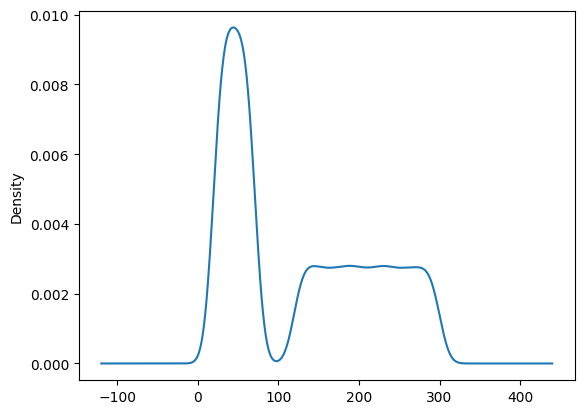

In [31]:
df['Delivery_Time_Min'].plot(kind='kde')

<Axes: xlabel='Delivery_Time_Min'>

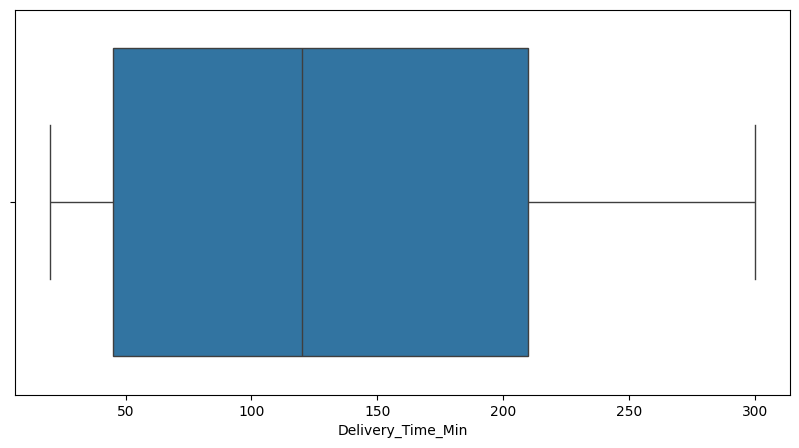

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Delivery_Time_Min')

<Axes: xlabel='Order_Value'>

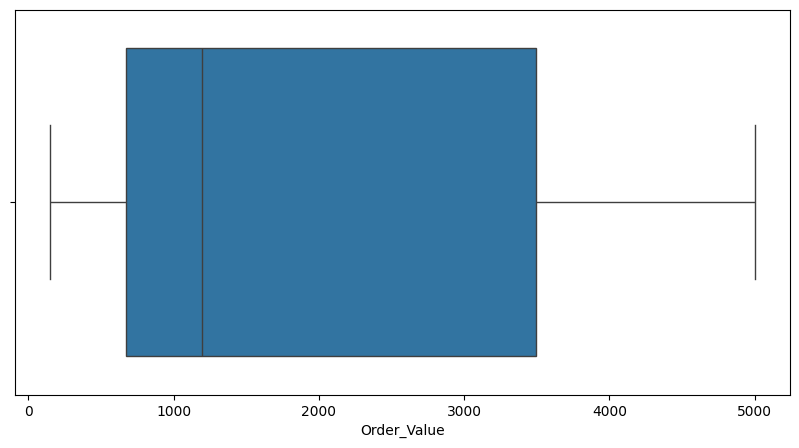

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Order_Value')

In [34]:
dtime_median=df['Delivery_Time_Min'].median()
df['Delivery_Time_Min'] = df['Delivery_Time_Min'].fillna(dtime_median)

In [35]:
dist_median=df['Distance_km'].median()
df['Distance_km'] = df['Distance_km'].fillna(dist_median)

In [36]:
df[(df['Order_Status']=='Delivered')&(df['Order_Value'].isna())]

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,0:00,187.0,15.75,NaN,NaN,NaN,UPI,Delivered,not applicable,DP563,5.0,4.4,Weekend,True,0.13
5,ORD000006,CUST3161,37.0,Other,Chennai,East,RES810,Restaurant_153,Mexican,7/9/2024,0:00,56.0,4.00,NaN,300.0,NaN,Card,Delivered,not applicable,DP119,3.0,4.6,Weekday,True,0.24
6,ORD000007,CUST2307,40.0,Other,Delhi,East,RES333,Restaurant_302,Chinese,2/14/2024,0:00,273.0,5.77,NaN,0.0,NaN,UPI,Delivered,not applicable,DP624,2.0,4.5,Weekday,True,0.02
11,ORD000012,CUST2651,39.0,Female,Chennai,South,RES230,Restaurant_43,Arabian,9/3/2024,0:00,233.0,9.97,NaN,100.0,NaN,Wallet,Delivered,not applicable,DP530,3.0,3.0,Weekday,False,0.22
13,ORD000014,CUST6301,39.0,Male,Chennai,East,RES816,Restaurant_328,Chinese,12/5/2024,0:00,294.0,9.97,NaN,50.0,NaN,Card,Delivered,not applicable,DP528,3.0,4.4,Weekday,True,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99983,ORD099984,CUST9034,39.0,Female,Bangalore,East,RES851,Restaurant_215,Mexican,1/15/2024,0:00,238.0,9.97,NaN,NaN,NaN,Card,Delivered,not applicable,DP383,3.0,3.1,Weekday,True,0.20
99984,ORD099985,CUST9156,34.0,Other,Bangalore,East,RES187,Restaurant_227,Mexican,5/14/2024,0:00,60.0,3.59,NaN,50.0,NaN,Wallet,Delivered,not applicable,DP473,2.0,4.9,Weekday,True,0.22
99988,ORD099989,CUST2640,46.0,Male,Hyderabad,West,RES391,Restaurant_78,Arabian,12/24/2024,0:00,192.0,9.97,NaN,300.0,NaN,Wallet,Delivered,not applicable,DP781,1.0,3.1,Weekday,False,0.08
99992,ORD099993,CUST6703,49.0,Other,Bangalore,North,RES868,Restaurant_265,Indian,4/9/2024,0:00,120.0,32.91,NaN,50.0,NaN,NaN,Delivered,not applicable,DP666,3.0,4.5,Weekday,True,0.18


In [37]:
restaurant_medians = df.groupby('Restaurant_ID')['Order_Value'].transform('median')

In [38]:
df.loc[df['Order_Status'] == 'Delivered', 'Order_Value'] =  df.loc[df['Order_Status'] == 'Delivered', 'Order_Value'].fillna(restaurant_medians)

In [39]:
df.loc[df['Order_Status'] == 'Cancelled', 'Order_Value'] =  df.loc[df['Order_Status'] == 'Cancelled', 'Order_Value'].fillna(0.0)

In [40]:
df.loc[df['Order_Status'] == 'Delivered', 'Discount_Applied'] =  df.loc[df['Order_Status'] == 'Delivered', 'Discount_Applied'].fillna(0.00)

In [41]:
df.loc[df['Order_Status'] == 'Cancelled', 'Discount_Applied'] =  df.loc[df['Order_Status'] == 'Cancelled', 'Discount_Applied'].fillna(0.00)

In [42]:
df.loc[df['Order_Status'] == 'Delivered', 'Final_Amount'] = df.loc[df['Order_Status'] == 'Delivered', 'Final_Amount'].fillna(df['Order_Value'] - df['Discount_Applied'])

In [43]:
df.loc[df['Order_Status'] == 'Cancelled', 'Final_Amount'] = df.loc[df['Order_Status'] == 'Cancelled', 'Final_Amount'].fillna(df['Order_Value'] - df['Discount_Applied'])

In [44]:
Payment_Mode=df['Payment_Mode'].mode()[0]
df['Payment_Mode'] = df['Payment_Mode'].fillna(Payment_Mode)

In [45]:
df['Profit_Margin'] = df['Profit_Margin'].clip(lower=0)

In [46]:
df['Final_Amount'] = (df['Order_Value'] - df['Discount_Applied']).clip(lower=0)

In [47]:
df['Restaurant_Rating'] = df['Restaurant_Rating'].apply(lambda x: 5.0 if x > 5.0 else x)

In [48]:
df['Price_Range'] = pd.cut(df['Order_Value'],
                            bins=[0, 1000, 2500, 4000, 5000],
                            labels=['Low (<1k)', 'Mid (1k-2.5k)', 'High (2.5k-4k)', 'Premium (4k+)'])

/tmp/ipykernel_566/618626648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Price_Range', y='Delivery_Time_Min', palette='Set2')


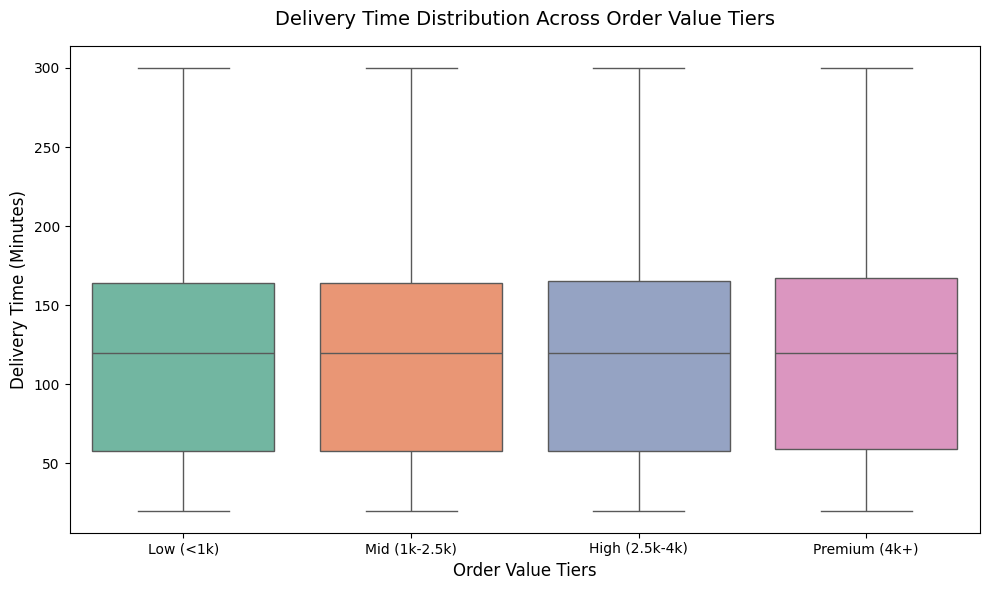

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Price_Range', y='Delivery_Time_Min', palette='Set2')

plt.title("Delivery Time Distribution Across Order Value Tiers", fontsize=14, pad=15)
plt.xlabel("Order Value Tiers", fontsize=12)
plt.ylabel("Delivery Time (Minutes)", fontsize=12)

plt.tight_layout()
plt.show()

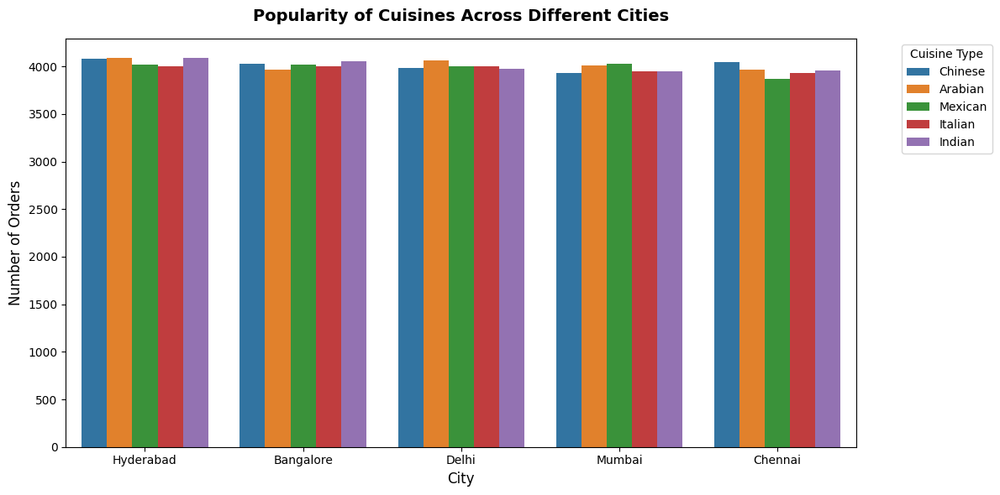

In [59]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='City',
    hue='Cuisine_Type',
    order=df['City'].value_counts().index,
    palette='tab10'
)
plt.title("Popularity of Cuisines Across Different Cities", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.legend(title="Cuisine Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

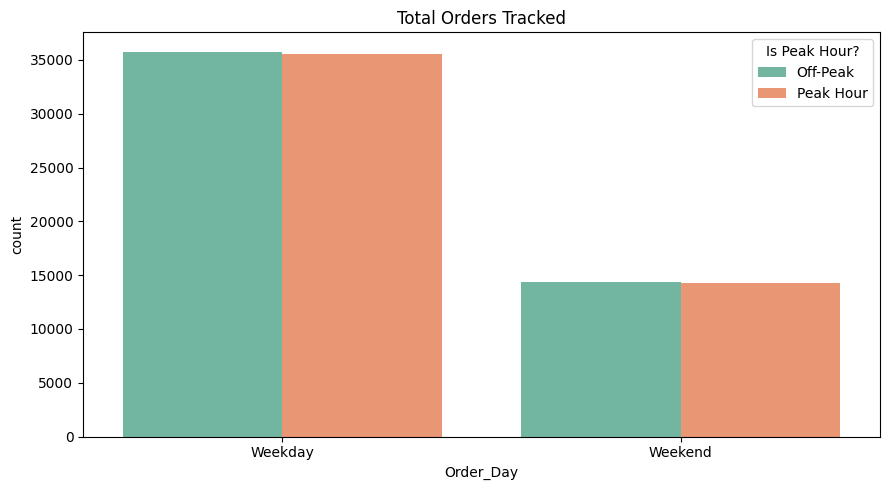

In [62]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x='Order_Day',
    hue='Peak_Hour',
    palette='Set2',
    order=['Weekday', 'Weekend']
)
plt.title("Day Classification", fontsize=12)
plt.title("Order Volume Split: Weekdays vs. Weekends", fontsize=14, pad=15, fontweight='bold')
plt.title("Total Orders Tracked", fontsize=12)
plt.legend(title="Is Peak Hour?", labels=["Off-Peak", "Peak Hour"])

plt.tight_layout()
plt.show()

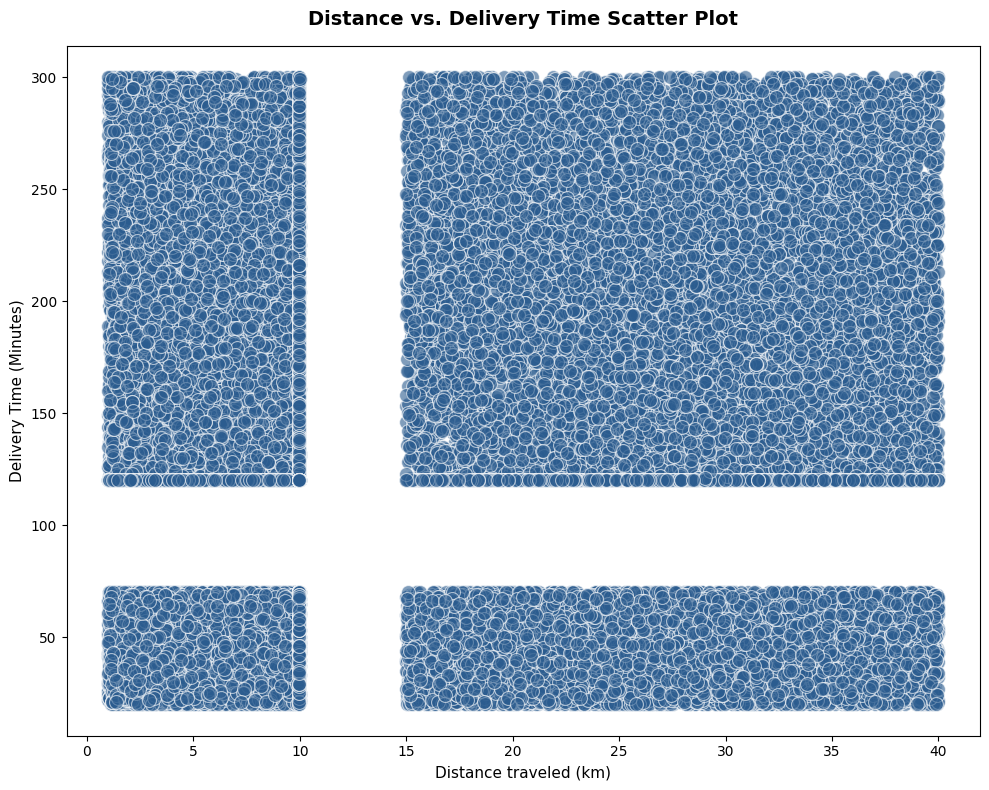

In [63]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='Distance_km',
    y='Delivery_Time_Min',
    s=100,                 # Size of the dots
    alpha=0.6,             # Transparancy (0 = invisible, 1 = completely solid)
    color='#2b5c8f'
)
plt.title("Distance vs. Delivery Time Scatter Plot", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Distance traveled (km)", fontsize=11)
plt.ylabel("Delivery Time (Minutes)", fontsize=11)

plt.tight_layout()
plt.show()

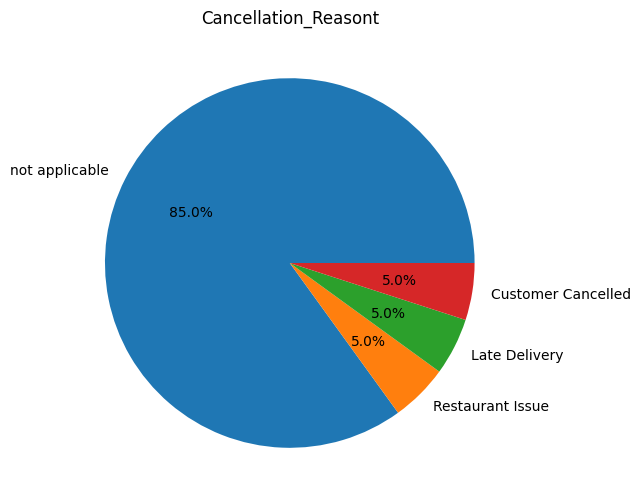

In [64]:
plt.figure(figsize=(12, 6))
plt.pie(x=df['Cancellation_Reason'].value_counts().values,
        labels=df['Cancellation_Reason'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Cancellation_Reasont")
plt.show()

Adding new column for data handling

In [65]:
df['Delivery_Performance'] = pd.cut(
    df['Delivery_Time_Min'],
    bins=[0, 30, 45, 90, float('inf')],
    labels=['Super Fast', 'On Time', 'Delayed', 'Severe Delay']
)

In [66]:
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Youth', 'Young Adults', 'Middle Aged', 'Senior']
)

In [67]:
df.head(10)


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Price_Range,Delivery_Performance,Age_Group
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,0:00,187.0,15.75,1189.0,0.0,1189.0,UPI,Delivered,not applicable,DP563,5.0,4.4,Weekend,True,0.13,Mid (1k-2.5k),Severe Delay,Youth
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,0:00,20.0,29.50,4869.0,20.0,4849.0,COD,Delivered,not applicable,DP369,5.0,4.7,Weekday,True,0.48,Premium (4k+),Super Fast,Young Adults
2,ORD000003,CUST1765,39.0,Male,Delhi,North,RES723,Restaurant_244,Arabian,12/8/2024,0:00,207.0,9.97,757.0,20.0,737.0,Wallet,Delivered,not applicable,DP580,4.0,4.9,Weekend,True,0.08,Low (<1k),Severe Delay,Young Adults
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,0:00,143.0,15.68,0.0,0.0,0.0,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,True,0.04,NaN,Severe Delay,Young Adults
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,0:00,51.0,9.60,372.0,20.0,352.0,Card,Delivered,not applicable,DP728,2.0,4.4,Weekend,False,0.12,Low (<1k),Delayed,Middle Aged
5,ORD000006,CUST3161,37.0,Other,Chennai,East,RES810,Restaurant_153,Mexican,7/9/2024,0:00,56.0,4.00,2215.0,300.0,1915.0,Card,Delivered,not applicable,DP119,3.0,4.6,Weekday,True,0.24,Mid (1k-2.5k),Delayed,Young Adults
6,ORD000007,CUST2307,40.0,Other,Delhi,East,RES333,Restaurant_302,Chinese,2/14/2024,0:00,273.0,5.77,2201.0,0.0,2201.0,UPI,Delivered,not applicable,DP624,2.0,4.5,Weekday,True,0.02,Mid (1k-2.5k),Severe Delay,Young Adults
7,ORD000008,CUST5865,39.0,Male,Delhi,North,RES696,Restaurant_41,Chinese,5/26/2024,0:00,120.0,21.69,3506.0,20.0,3486.0,UPI,Delivered,not applicable,DP316,5.0,3.8,Weekend,True,0.18,High (2.5k-4k),Severe Delay,Young Adults
8,ORD000009,CUST4356,39.0,Other,Delhi,Central,RES780,Restaurant_155,Italian,9/7/2024,0:00,120.0,8.55,525.0,100.0,425.0,Card,Delivered,not applicable,DP531,2.0,3.7,Weekend,True,0.08,Low (<1k),Severe Delay,Young Adults
9,ORD000010,CUST2404,39.0,Female,Delhi,South,RES155,Restaurant_368,Chinese,1/22/2024,0:00,120.0,32.54,4691.0,50.0,4641.0,Card,Delivered,not applicable,DP338,4.0,4.5,Weekday,True,0.03,Premium (4k+),Severe Delay,Young Adults


Connecting To Mysql

In [68]:
from sqlalchemy import create_engine

# Install pymysql if not already installed
!pip install pymysql

username = 'root'
password = 'Gayathri091022'
host = 'localhost'
port = 3306
database = 'mydb'
engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00


outputs

In [72]:
Total_number_orders=df['Order_ID'].count()
Total_number_orders

np.int64(100000)

In [73]:
Total_revenue=df['Order_Value'].sum()
Total_revenue

np.float64(186639705.0)

In [74]:
Average_order_value=df['Order_Value'].mean()
Average_order_value

np.float64(1866.39705)

In [75]:
Average_delivery_time=df['Delivery_Time_Min'].mean()
Average_delivery_time

np.float64(124.98203)

In [76]:
Average_delivery_rating=df['Delivery_Rating'].mean()
Average_delivery_rating

np.float64(2.99293)

In [78]:
cancellation_rate = (df['Order_Status'] == 'Cancelled').mean()
print(f"Cancellation Rate: {cancellation_rate:.2%}")

Cancellation Rate: 15.04%
